In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definir ruta y cargar dataset procesado GFS-OAQ
PROJECT_ROOT = Path.cwd()
PARQUET_FILE = PROJECT_ROOT / "data" / "processed" / "gfs" / "gfs_oaq_dataset_competo.parquet"

if not PARQUET_FILE.exists():
    raise FileNotFoundError(f"El archivo Parquet no fue localizado en: {PARQUET_FILE}")

df_gfs = pd.read_parquet(PARQUET_FILE)

# 2. Auditoría Temporal e Integridad del Dataset
print("==================================================================")
print("             AUDITORÍA INICIAL DEL DATASET GFS-OAQ                ")
print("==================================================================")
print(f"Dimensiones del Dataset:      {df_gfs.shape[0]} registros | {df_gfs.shape[1]} columnas")
print(f"Periodo de Corridas (Run):    {df_gfs['run_time'].min()} a {df_gfs['run_time'].max()}")
print(f"Periodo de Pronóstico (Valid): {df_gfs['valid_time'].min()} a {df_gfs['valid_time'].max()}")
print("==================================================================")

# Inspección de las primeras filas
df_gfs.head()

             AUDITORÍA INICIAL DEL DATASET GFS-OAQ                
Dimensiones del Dataset:      5688 registros | 13 columnas
Periodo de Corridas (Run):    2026-01-04 00:00:00 a 2026-06-10 18:00:00
Periodo de Pronóstico (Valid): 2026-01-04 00:00:00 a 2026-06-11 18:00:00


,run_time,valid_time,fxx,RH700,RH500,T700,T500,U700,V700,Omega700,PWAT,TCC,HCC
0,2026-01-04,2026-01-04 00:00:00,0,91.312443,91.674082,283.700363,267.964630,0.417669,-0.584670,-0.050903,22.276166,97.952539,30.418320
1,2026-01-04,2026-01-04 03:00:00,3,90.322461,81.074258,283.173400,268.179617,-0.903806,-0.699117,-0.222174,21.465899,86.310279,60.573580
2,2026-01-04,2026-01-04 06:00:00,6,94.185723,81.843179,282.375250,267.690214,-0.589093,-0.457206,-0.100807,19.891928,90.415361,96.745097
3,2026-01-04,2026-01-04 09:00:00,9,91.325060,65.347603,282.198793,267.824467,-1.138571,-0.521067,-0.140458,18.700999,99.702997,100.000000
4,2026-01-04,2026-01-04 12:00:00,12,88.441559,78.198421,281.695580,267.417758,-1.268383,0.499028,-0.008456,18.064971,92.339380,57.785940


In [2]:
print("==================================================================")
print("         DIAGNÓSTICO ESTADÍSTICO Y CONTROL DE CALIDAD             ")
print("==================================================================")

# 1. Calcular el resumen estadístico base
df_stats = df_gfs.describe().T

# 2. Inyectar métricas de control de calidad (Nulos y tipos de datos)
df_stats["Missing Values"] = df_gfs[df_stats.index].isna().sum()
df_stats["Dtype"] = df_gfs[df_stats.index].dtypes

# Reordenar columnas para una lectura ejecutiva
column_order = ["Dtype", "Missing Values", "count", "mean", "std", "min", "50%", "max"]

print("Resumen de variables numéricas y nulos detectados:")
df_stats[column_order].round(3)

         DIAGNÓSTICO ESTADÍSTICO Y CONTROL DE CALIDAD             
Resumen de variables numéricas y nulos detectados:


,Dtype,Missing Values,count,mean,std,min,50%,max
run_time,datetime64[ns],0,5688,2026-03-23 20:59:59.999999744,NaN,2026-01-04 00:00:00,2026-03-23 21:00:00,2026-06-10 18:00:00
valid_time,datetime64[ns],0,5688,2026-03-24 09:00:00,NaN,2026-01-04 00:00:00,2026-03-24 09:00:00,2026-06-11 18:00:00
fxx,int64,0,5688.0,12.0,7.746648,0.0,12.0,24.0
RH700,float64,0,5688.0,79.691726,12.245815,35.739479,81.94051,99.45994
RH500,float64,0,5688.0,73.461253,19.476417,11.36288,77.687469,99.94584
T700,float64,0,5688.0,284.044959,1.84938,280.556624,283.540176,290.752349
T500,float64,0,5688.0,268.462711,0.825439,265.688426,268.41071,272.092578
U700,float64,0,5688.0,-0.350126,1.431892,-6.072653,-0.436866,3.919412
V700,float64,0,5688.0,-0.444073,1.02559,-4.201722,-0.461545,3.949678
Omega700,float64,0,5688.0,-0.104478,0.165593,-1.022128,-0.072217,0.461539


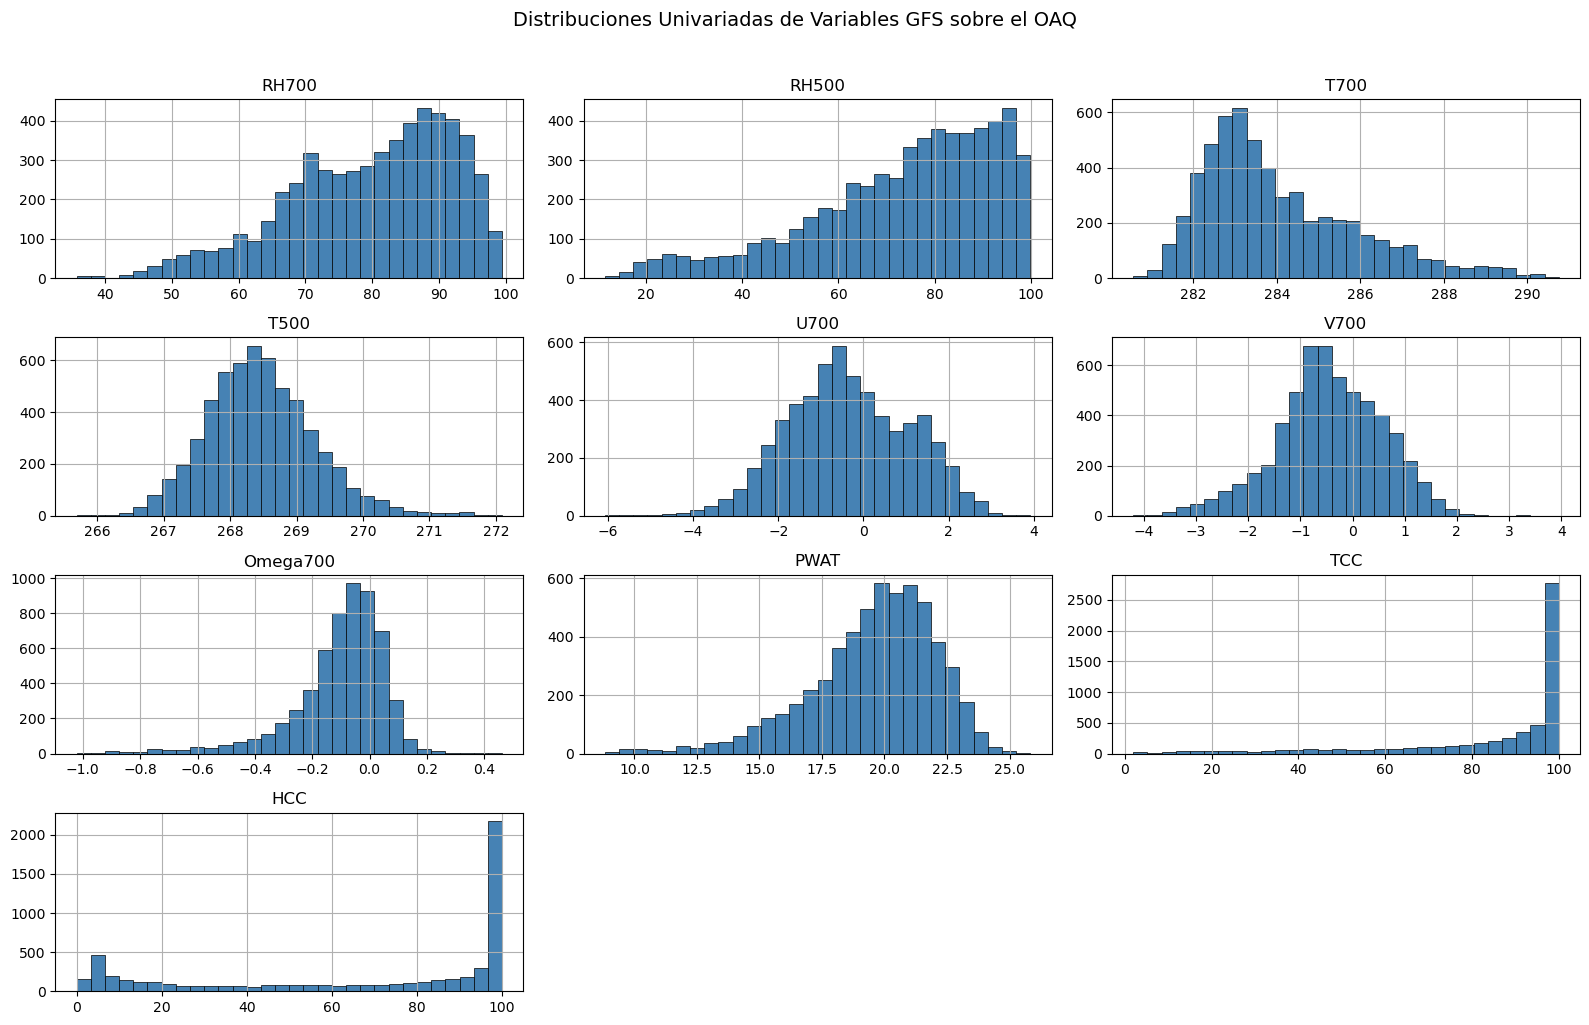

In [4]:
# 1. Definición explícita de las variables meteorológicas bajo estudio
variables_meteo = [
    "RH700", "RH500", "T700", "T500", 
    "U700", "V700", "Omega700", "PWAT", 
    "TCC", "HCC"
]

# 2. Graficación unificada de distribuciones
df_gfs[variables_meteo].hist(
    figsize=(16, 10),
    bins=30,
    grid=True,
    color="steelblue",
    edgecolor="black",
    linewidth=0.5
)

plt.suptitle("Distribuciones Univariadas de Variables GFS sobre el OAQ", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import normaltest

# 1. Construcción de métricas estadísticas de forma
df_resumen_forma = pd.DataFrame({
    "Media": df_gfs[variables_meteo].mean(),
    "Mediana": df_gfs[variables_meteo].median(),
    "Desv. Est. (std)": df_gfs[variables_meteo].std(),
    "Asimetría (Skew)": df_gfs[variables_meteo].skew(),
    "Curtosis (Kurt)": df_gfs[variables_meteo].kurtosis()
})

# Redondear las métricas de forma nativa a 3 decimales
df_resumen_forma = df_resumen_forma.round(3)

# 2. Inyectar p-values calculados omitiendo NaN y formateados en notación científica
p_values_normalidad = []
for var in variables_meteo:
    _, p = normaltest(df_gfs[var], nan_policy="omit")
    p_values_normalidad.append(f"{p:.3e}")

df_resumen_forma["Normaltest p-value"] = p_values_normalidad

print("=====================================================================================")
print("          CARACTERIZACIÓN FORMAL DE DISTRIBUCIONES Y NORMALIDAD (GFS-OAQ)            ")
print("=====================================================================================")

# Desplegar la tabla final limpia
df_resumen_forma

          CARACTERIZACIÓN FORMAL DE DISTRIBUCIONES Y NORMALIDAD (GFS-OAQ)            


,Media,Mediana,Desv. Est. (std),Asimetría (Skew),Curtosis (Kurt),Normaltest p-value
RH700,79.692,81.941,12.246,-0.652,-0.193,9.463e-77
RH500,73.461,77.687,19.476,-0.904,0.215,2.922e-128
T700,284.045,283.540,1.849,0.979,0.508,2.668e-151
T500,268.463,268.411,0.825,0.510,0.910,1.131e-69
U700,-0.350,-0.437,1.432,-0.034,-0.329,5.486e-09
V700,-0.444,-0.462,1.026,-0.252,0.208,2.396e-15
Omega700,-0.104,-0.072,0.166,-1.634,4.420,0.000e+00
PWAT,19.555,19.964,2.545,-0.933,1.205,1.013e-163
TCC,84.779,96.323,22.712,-1.741,2.157,0.000e+00
HCC,66.804,86.249,36.999,-0.643,-1.248,0.000e+00


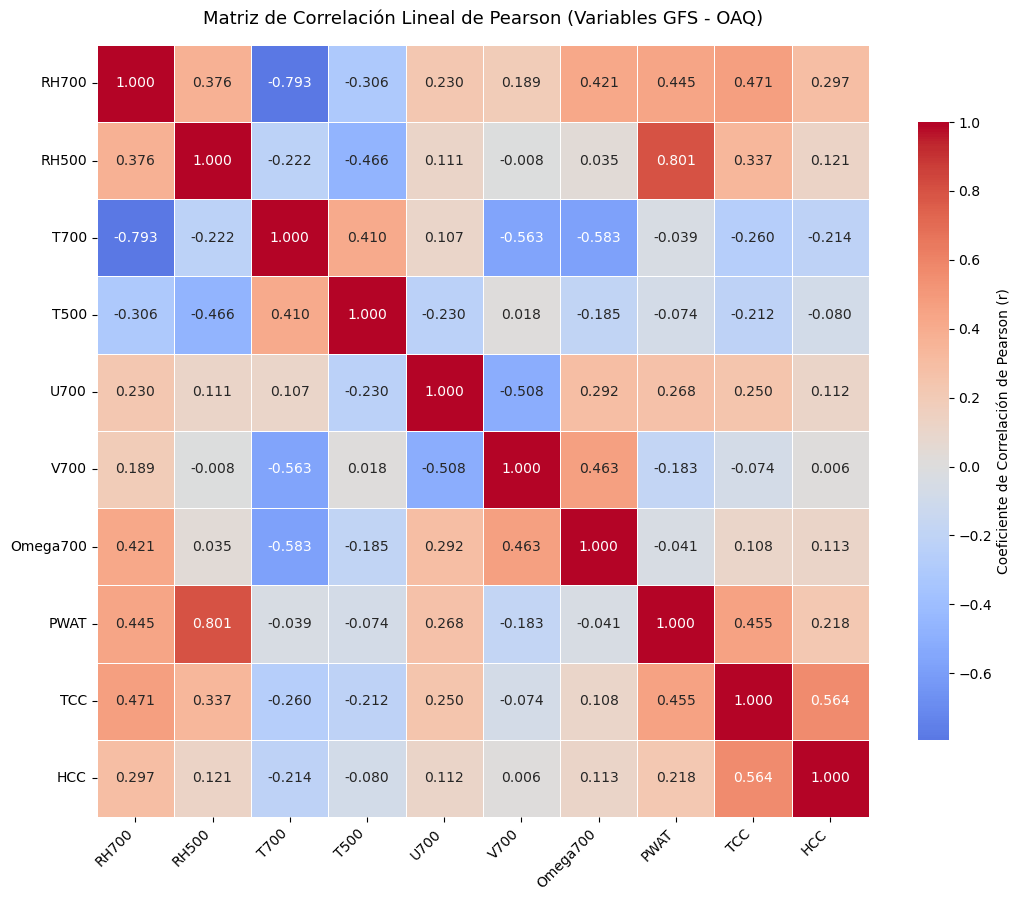

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aislar únicamente las variables meteorológicas del estudio para evitar ruido en la matriz
variables_meteo = [
    "RH700", "RH500", "T700", "T500", 
    "U700", "V700", "Omega700", "PWAT", 
    "TCC", "HCC"
]

# 2. Calcular la matriz de correlación de Pearson una sola vez
corr_matrix = df_gfs[variables_meteo].corr()

# 3. Configuración del mapa de calor estadístico
plt.figure(figsize=(11, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",          # Tres decimales para rigor en publicaciones científicas
    cmap="coolwarm",    # Escala divergente perfecta para correlaciones positivas/negativas
    center=0,
    square=True,
    linewidths=0.7,
    cbar_kws={"label": "Coeficiente de Correlación de Pearson (r)", "shrink": 0.8} # CORREGIDO: cbar_kws
)

plt.title("Matriz de Correlación Lineal de Pearson (Variables GFS - OAQ)", fontsize=13, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [10]:
# 1. Extraer la componente horaria basada en el tiempo de validez del pronóstico
df_gfs["hour"] = df_gfs["valid_time"].dt.hour

# 2. Calcular el ciclo diurno promedio para las variables de interés temporal
variables_ciclo = ["RH700", "RH500", "PWAT", "TCC", "HCC"]
ciclo_diurno = df_gfs.groupby("hour")[variables_ciclo].mean()

# 3. Estandarización matemática (Anomalía Z) para aislar patrones de comportamiento físico
variables_core = ["RH700", "PWAT", "TCC"]
ciclo_norm = (ciclo_diurno[variables_core] - ciclo_diurno[variables_core].mean()) / ciclo_diurno[variables_core].std()

print("======================================================================")
# Mostrar el DataFrame base redondeado para verificar los extremos del ciclo diurno (Noche vs. Tarde)
ciclo_diurno.round(3)

,RH700,RH500,PWAT,TCC,HCC
hour,,,,,
0,84.868,77.423,20.911,89.108,69.298
3,86.322,74.773,20.175,88.138,75.786
6,85.804,74.291,19.446,86.606,74.019
9,84.794,73.726,18.850,86.884,72.580
12,82.227,70.711,18.195,82.687,62.918
15,70.004,67.842,18.081,75.020,58.761
18,64.243,71.540,19.640,78.347,54.941
21,79.679,77.354,21.153,92.039,67.641


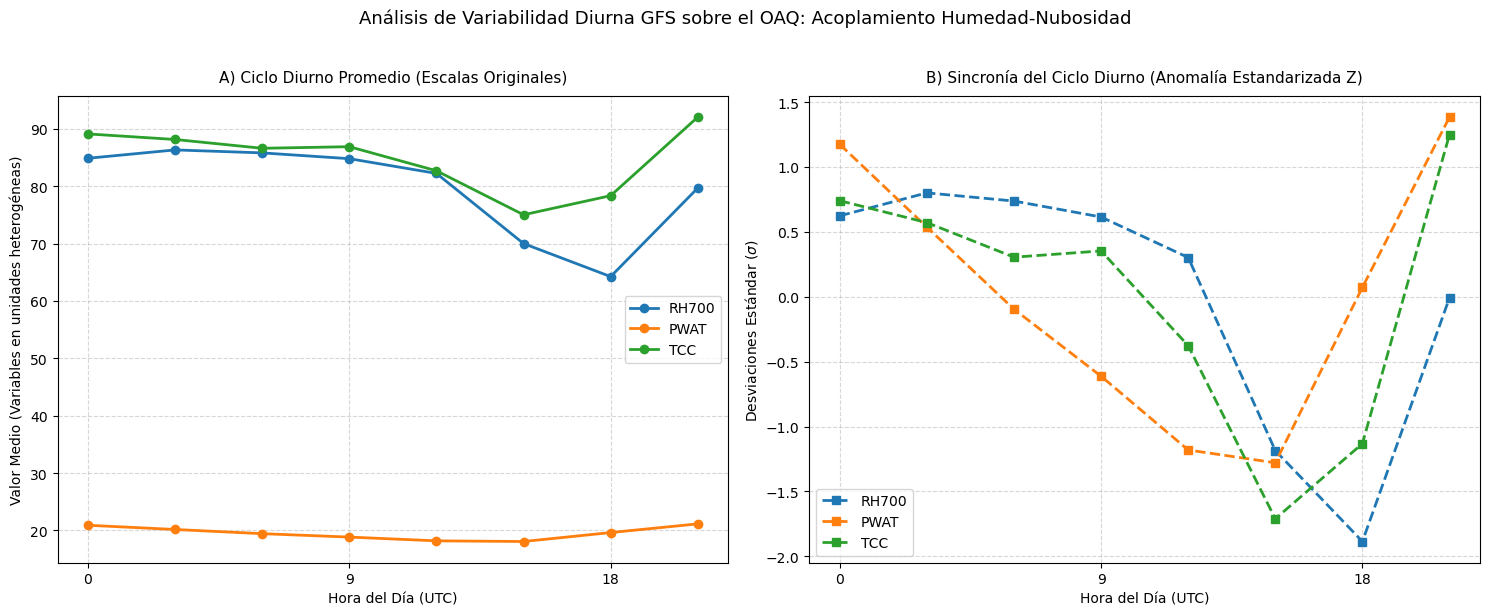

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- PANEL A: VALORES CRUDOS (Problema de escalas físicas) ---
for var in variables_core:
    axes[0].plot(ciclo_diurno.index, ciclo_diurno[var], marker="o", linewidth=2, label=var)

axes[0].set_title("A) Ciclo Diurno Promedio (Escalas Originales)", fontsize=11, pad=10)
axes[0].set_xlabel("Hora del Día (UTC)")
axes[0].set_ylabel("Valor Medio (Variables en unidades heterogéneas)")
axes[0].set_xticks(ciclo_diurno.index[::3]) # Saltos de 3 horas para limpiar el eje
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# --- PANEL B: VALORES ESTANDARIZADOS (Alineación física/sincronía) ---
colores = ["#1f77b4", "#ff7f0e", "#2ca02c"] # Mantener la consistencia de colores entre paneles
for i, col in enumerate(ciclo_norm.columns):
    axes[1].plot(ciclo_norm.index, ciclo_norm[col], marker="s", linewidth=2, linestyle="--", color=colores[i], label=col)

axes[1].set_title("B) Sincronía del Ciclo Diurno (Anomalía Estandarizada Z)", fontsize=11, pad=10)
axes[1].set_xlabel("Hora del Día (UTC)")
axes[1].set_ylabel("Desviaciones Estándar ($\sigma$)")
axes[1].set_xticks(ciclo_diurno.index[::3])
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

# Título principal de la figura del artículo
plt.suptitle("Análisis de Variabilidad Diurna GFS sobre el OAQ: Acoplamiento Humedad-Nubosidad", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# 1. Análisis Mensual Promedio
df_gfs["month"] = df_gfs["valid_time"].dt.month
ciclo_mensual = df_gfs.groupby("month")[["RH700", "PWAT", "TCC", "HCC"]].mean()

# Conteo de registros por mes para asegurar representatividad estadística
print("Registros válidos por mes:")
print(df_gfs["month"].value_counts().sort_index().to_string())

# 2. Construcción de la Serie Temporal Diaria (Remoción de ruido diurno)
serie_diaria = df_gfs.groupby(df_gfs["valid_time"].dt.date)[["RH700", "PWAT", "TCC"]].mean()

# 3. Análisis de Correlación Temporal con Desfase (Lags)
print("\n=======================================================")
print("     ANÁLISIS DE CORRELACIÓN CON DESFASE (LAG ANALYSIS) ")
print("=======================================================")
print(f"Humedad vs Nubosidad (Mismo día):     r = {serie_diaria['RH700'].corr(serie_diaria['TCC']):.3f}")
print(f"Humedad vs Nubosidad (Lag +1 día):    r = {serie_diaria['RH700'].corr(serie_diaria['TCC'].shift(-1)):.3f}")
print(f"Humedad vs Nubosidad (Lag +2 días):   r = {serie_diaria['RH700'].corr(serie_diaria['TCC'].shift(-2)):.3f}")

Registros válidos por mes:
month
1     992
2    1008
3    1116
4    1080
5    1116
6     376

     ANÁLISIS DE CORRELACIÓN CON DESFASE (LAG ANALYSIS) 
Humedad vs Nubosidad (Mismo día):     r = 0.645
Humedad vs Nubosidad (Lag +1 día):    r = 0.603
Humedad vs Nubosidad (Lag +2 días):   r = 0.464


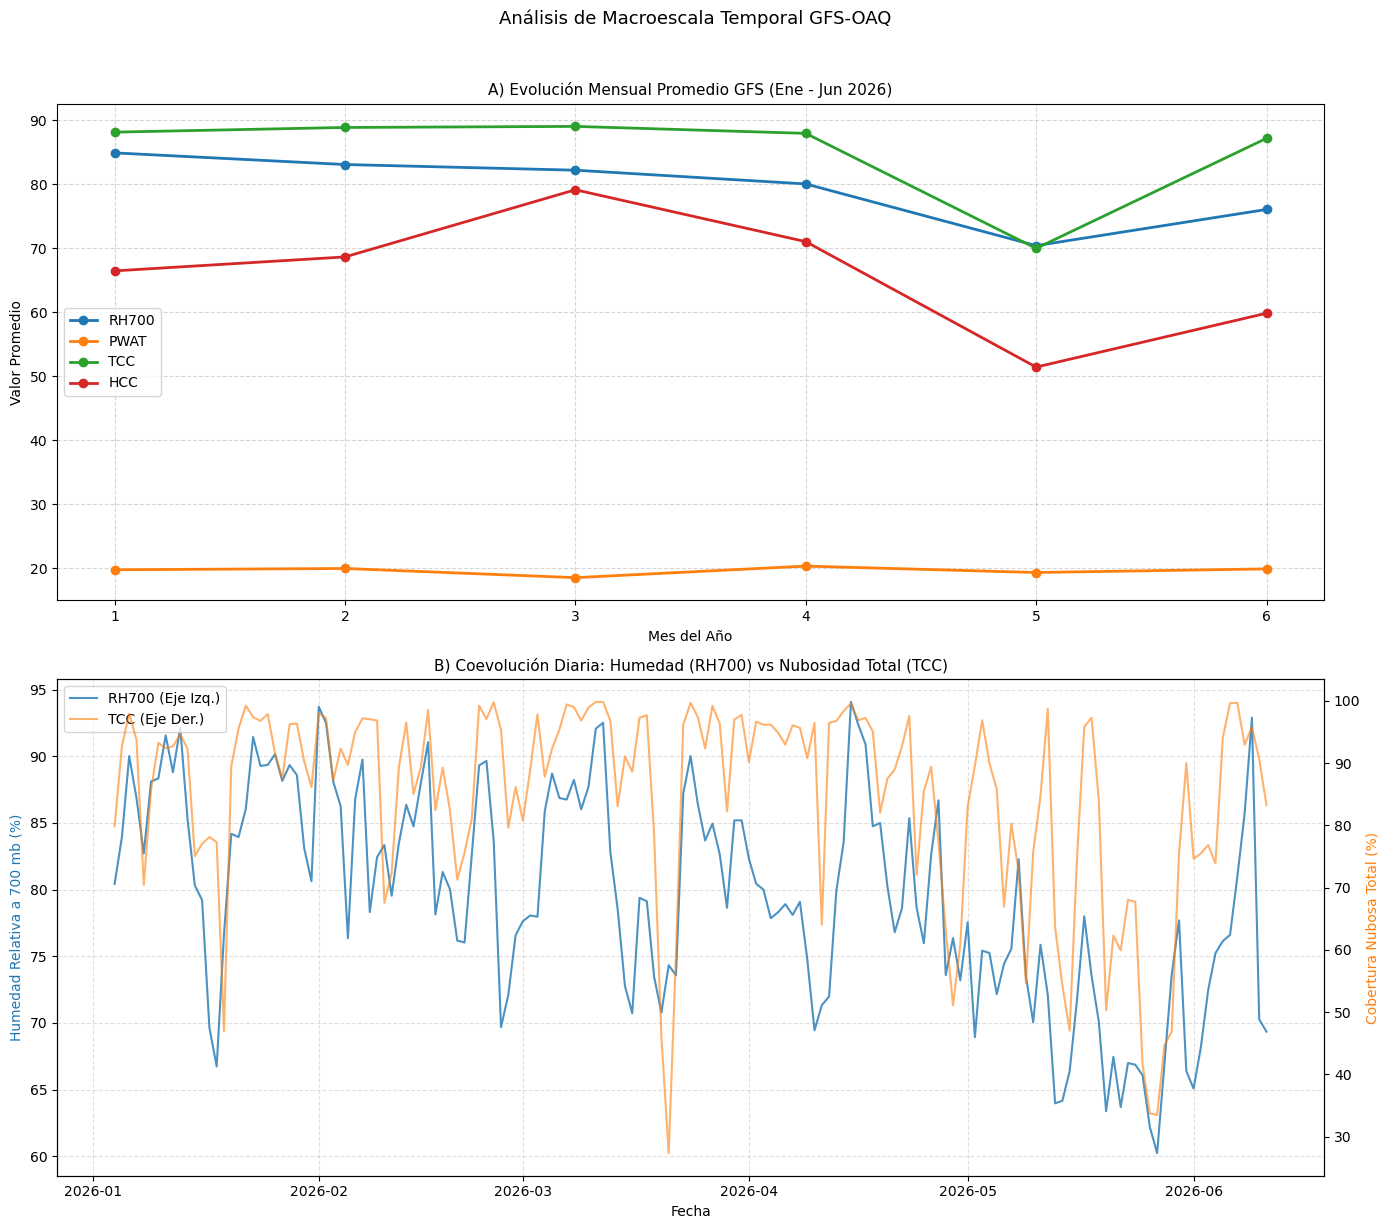

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- PANEL A: EVOLUCIÓN MENSUAL PROMEDIO ---
for var in ciclo_mensual.columns:
    axes[0].plot(ciclo_mensual.index, ciclo_mensual[var], marker="o", linewidth=2, label=var)
axes[0].set_title("A) Evolución Mensual Promedio GFS (Ene - Jun 2026)", fontsize=11)
axes[0].set_xlabel("Mes del Año")
axes[0].set_ylabel("Valor Promedio")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# --- PANEL B: SERIE DIARIA CON DOBLE EJE Y (Sincronía RH700 vs TCC) ---
ax2_left = axes[1]
ax2_right = axes[1].twinx() # Compartir eje X para el segundo eje Y

line1 = ax2_left.plot(serie_diaria.index, serie_diaria["RH700"], color="#1f77b4", alpha=0.8, label="RH700 (Eje Izq.)")
line2 = ax2_right.plot(serie_diaria.index, serie_diaria["TCC"], color="#ff7f0e", alpha=0.6, label="TCC (Eje Der.)")

ax2_left.set_title("B) Coevolución Diaria: Humedad (RH700) vs Nubosidad Total (TCC)", fontsize=11)
ax2_left.set_xlabel("Fecha")
ax2_left.set_ylabel("Humedad Relativa a 700 mb (%)", color="#1f77b4")
ax2_right.set_ylabel("Cobertura Nubosa Total (%)", color="#ff7f0e")
ax2_left.grid(True, linestyle="--", alpha=0.4)

# Unificar las leyendas de ambos ejes en una sola caja
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2_left.legend(lines, labels, loc="upper left")

plt.suptitle("Análisis de Macroescala Temporal GFS-OAQ", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import linregress

# 1. Calcular la matriz de correlación diaria completa
matriz_corr_diaria = serie_diaria.corr()

# 2. Ajuste de Regresión Lineal Simple (RH700 como predictor de TCC)
res = linregress(serie_diaria["RH700"], serie_diaria["TCC"])

print("=======================================================")
print("     MATRIZ DE CORRELACIÓN A ESCALA DIARIA (PROMEDIOS)  ")
print("=======================================================")
display(matriz_corr_diaria.round(3))

print("\n=======================================================")
print("     DIAGNÓSTICO DE REGRESIÓN LINEAL (RH700 -> TCC)     ")
print("=======================================================")
print(f"Coeficiente de Correlación (r):  {res.rvalue:.4f}")
print(f"Coeficiente de Det. (R²):        {res.rvalue**2:.4f}  (Explica el {res.rvalue**2*100:.1f}% de la varianza)")
print(f"Pendiente (Slope):               {res.slope:.4f}")
print(f"Intercepto:                      {res.intercept:.4f}")
print(f"Valor p de significancia:        {res.pvalue:.3e}")

     MATRIZ DE CORRELACIÓN A ESCALA DIARIA (PROMEDIOS)  


,RH700,PWAT,TCC
RH700,1.000,0.571,0.645
PWAT,0.571,1.000,0.566
TCC,0.645,0.566,1.000



     DIAGNÓSTICO DE REGRESIÓN LINEAL (RH700 -> TCC)     
Coeficiente de Correlación (r):  0.6454
Coeficiente de Det. (R²):        0.4166  (Explica el 41.7% de la varianza)
Pendiente (Slope):               1.2909
Intercepto:                      -18.0668
Valor p de significancia:        4.160e-20


In [24]:
import numpy as np
# 1. Definición de vectores reales (Escala Diaria)
y_real = serie_diaria["TCC"]
x_rh = serie_diaria["RH700"]
ss_tot = np.sum((y_real - y_real.mean())**2)

# 2. AJUSTE LINEAL (Grado 1)
coef_lin = np.polyfit(x_rh, y_real, deg=1)
y_pred_lin = np.polyval(coef_lin, x_rh)
r2_lin = 1 - (np.sum((y_real - y_pred_lin)**2) / ss_tot)

# Métricas de error del modelo lineal
residuos_lin = y_real - y_pred_lin
mae_lin = np.mean(np.abs(residuos_lin))
rmse_lin = np.sqrt(np.mean(residuos_lin**2))

# 3. AJUSTE CUADRÁTICO (Grado 2)
coef_quad = np.polyfit(x_rh, y_real, deg=2)
y_pred_quad = np.polyval(coef_quad, x_rh)
r2_quad = 1 - (np.sum((y_real - y_pred_quad)**2) / ss_tot)

print("==================================================================")
print("     DIAGNÓSTICO COMPARATIVO DE AJUSTE (RH700 -> TCC DIARIO)       ")
print("==================================================================")
print(f"MÉTRICAS MODELO LINEAL:")
print(f"  └─ Coeficiente R²:          {r2_lin:.4f}")
print(f"  └─ Error Medio Abs. (MAE):   {mae_lin:.2f} %")
print(f"  └─ Raíz Error Cuad. (RMSE):  {rmse_lin:.2f} %")
print(f"  └─ Ecuación:                TCC = {coef_lin[0]:.4f}*(RH700) + {coef_lin[1]:.4f}")
print("------------------------------------------------------------------")
print(f"MÉTRICAS MODELO CUADRÁTICO:")
print(f"  └─ Coeficiente R²:          {r2_quad:.4f}")
print(f"  └─ Ganancia neta de R²:     {r2_quad - r2_lin:+.4f}")
print(f"  └─ Ecuación:                TCC = {coef_quad[0]:.4f}*(RH700²) + {coef_quad[1]:.4f}*(RH700) + {coef_quad[2]:.4f}")

     DIAGNÓSTICO COMPARATIVO DE AJUSTE (RH700 -> TCC DIARIO)       
MÉTRICAS MODELO LINEAL:
  └─ Coeficiente R²:          0.4166
  └─ Error Medio Abs. (MAE):   8.85 %
  └─ Raíz Error Cuad. (RMSE):  12.11 %
  └─ Ecuación:                TCC = 1.2909*(RH700) + -18.0668
------------------------------------------------------------------
MÉTRICAS MODELO CUADRÁTICO:
  └─ Coeficiente R²:          0.4483
  └─ Ganancia neta de R²:     +0.0317
  └─ Ecuación:                TCC = -0.0413*(RH700²) + 7.7936*(RH700) + -271.1262


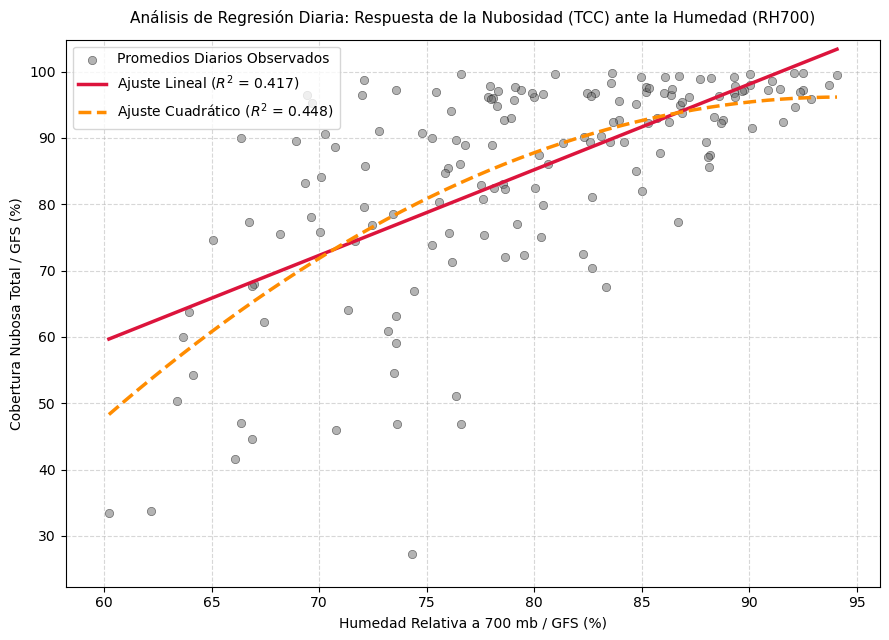

In [25]:
plt.figure(figsize=(9, 6.5))

# 1. Graficar los datos reales observados
plt.scatter(x_rh, y_real, color="dimgray", alpha=0.5, edgecolor="black", linewidth=0.5, label="Promedios Diarios Observados")

# 2. Generar una línea continua suave para los modelos ajustados
x_curva = np.linspace(x_rh.min(), x_rh.max(), 200)
y_curva_lin = np.polyval(coef_lin, x_curva)
y_curva_quad = np.polyval(coef_quad, x_curva)

# 3. Superponer líneas de tendencia
plt.plot(x_curva, y_curva_lin, color="crimson", linewidth=2.5, 
         label=f"Ajuste Lineal ($R^2$ = {r2_lin:.3f})")
plt.plot(x_curva, y_curva_quad, color="darkorange", linewidth=2.5, linestyle="--", 
         label=f"Ajuste Cuadrático ($R^2$ = {r2_quad:.3f})")

# Propiedades estéticas del gráfico científico
plt.title("Análisis de Regresión Diaria: Respuesta de la Nubosidad (TCC) ante la Humedad (RH700)", fontsize=11, pad=12)
plt.xlabel("Humedad Relativa a 700 mb / GFS (%)", fontsize=10)
plt.ylabel("Cobertura Nubosa Total / GFS (%)", fontsize=10)
plt.xlim(x_rh.min() - 2, x_rh.max() + 2)
plt.ylim(y_real.min() - 5, y_real.max() + 5)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

plt.show()